# Assignment 02
The following assignment is a step-by-step process to implement a multiclass classification using Iris dataset.

**Note:**

- Please note that every question has 0.5 and it provides five out of total ten marks for the assignment. 5/10%

The video presentation 5/10%.

Without YouTube presentation you receive no mark for the submission.


In [219]:
#00 The iris.csv file (Iris dataset) is located in the Assignment folder below the current ipynb file.

 **Important Note:** We are NOT allowed to import the dataset from Keras. We need to upload the provided iris.csv file to colab from our Google Drive.

In [220]:
#00 1st, upload the iris.csv into your Google Drive (your Colab folder).

In [221]:
#01-a Find the path of iris.csv file, and save it in a variable called fileName.

In [222]:
import os

filename = "/content/Assignment_02_iris.csv"
print("Path:", filename)

Path: /content/Assignment_02_iris.csv


In [223]:
#01-b Read the content of the iris.csv file and save it in a variable, named iris.

In [224]:
import pandas as pd
iris = pd.read_csv(filename)

In [225]:
#01-c Show the first 5 rows of the dataframe.

In [226]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


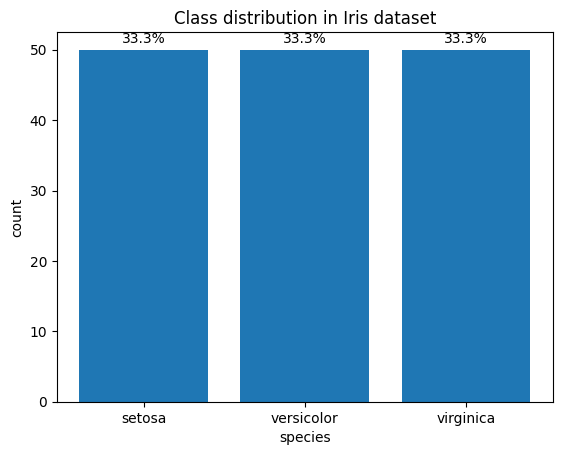

In [227]:
import matplotlib.pyplot as plt

counts = iris["species"].value_counts()
total = len(iris)

plt.figure()
bars = plt.bar(counts.index, counts.values)

plt.title("Class distribution in Iris dataset")
plt.xlabel("species")
plt.ylabel("count")

for i, v in enumerate(counts.values):
    percent = v / total * 100
    plt.text(i, v + 1, f"{percent:.1f}%", ha="center")

plt.show()

As you see, the last column contains strings. We want to convert these strings to integers,  and we can work with them easily in our Neural Network model.

setosa -> 0

versicolor -> 1

virginica -> 2

In [228]:
#2-a Convert the last column strings to integers, as
# setosa -> 0
# versicolor -> 1
# virginica -> 2

In [229]:
iris["species"] = iris["species"].astype(str).str.strip().str.lower()

iris["species"] = iris["species"].map({
    "setosa": 0,
    "versicolor": 1,
    "virginica": 2
})

In [230]:
print("NaNs after map:", iris["species"].isna().sum())
print("Unique:", sorted(iris["species"].unique()))

NaNs after map: 0
Unique: [np.int64(0), np.int64(1), np.int64(2)]


In [231]:
#2-b Now, check the first 5 elements of the iris dataset once again:

In [232]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


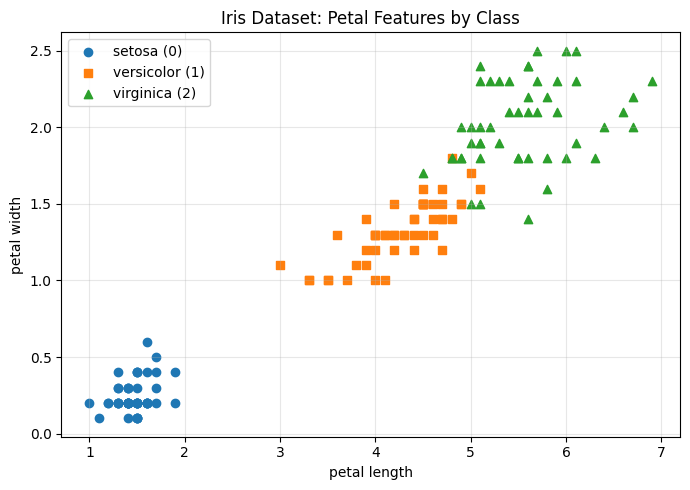

In [233]:
plt.figure(figsize=(7,5))

# setosa
plt.scatter(
    iris[iris["species"] == 0]["petal_length"],
    iris[iris["species"] == 0]["petal_width"],
    marker="o",
    label="setosa (0)"
)

# versicolor
plt.scatter(
    iris[iris["species"] == 1]["petal_length"],
    iris[iris["species"] == 1]["petal_width"],
    marker="s",
    label="versicolor (1)"
)

# virginica
plt.scatter(
    iris[iris["species"] == 2]["petal_length"],
    iris[iris["species"] == 2]["petal_width"],
    marker="^",
    label="virginica (2)"
)

plt.xlabel("petal length")
plt.ylabel("petal width")
plt.title("Iris Dataset: Petal Features by Class")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [234]:
#03-a Select the first four columns of the dataframe as the Data and call the data x.

In [235]:
x = iris.iloc[:, 0:4]
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [236]:
#03-b Select the last column as the label and call it y.

In [237]:
y = iris.iloc[:, 4]
y.head()

,species
0,0
1,0
2,0
3,0
4,0


In [238]:
#04 Now, it is the time to split the data (x) and the label (y) into training and testin segments,
#   and call them parts x_train,x_test,y_train,y_test.

In [239]:
#04-a Split the data, and label ito training and testing segments, while the size of test data is 20%,
#     and use randome_state = 123 to make all the answers similar in the whole class.

In [240]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=123
)

In [241]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (120, 4)
x_test : (30, 4)
y_train: (120,)
y_test : (30,)


In [242]:
#04-b Check the first five rows of  x_train,x_test,y_train,y_test.

In [243]:
print(x_train.head())

     sepal_length  sepal_width  petal_length  petal_width
130           7.4          2.8           6.1          1.9
119           6.0          2.2           5.0          1.5
29            4.7          3.2           1.6          0.2
0             5.1          3.5           1.4          0.2
62            6.0          2.2           4.0          1.0


In [244]:
print(x_test.head())

     sepal_length  sepal_width  petal_length  petal_width
72            6.3          2.5           4.9          1.5
112           6.8          3.0           5.5          2.1
132           6.4          2.8           5.6          2.2
88            5.6          3.0           4.1          1.3
37            4.9          3.1           1.5          0.1


In [245]:
print(y_train.head())

130    2
119    2
29     0
0      0
62     1
Name: species, dtype: int64


In [246]:
print(y_test.head())

72     1
112    2
132    2
88     1
37     0
Name: species, dtype: int64


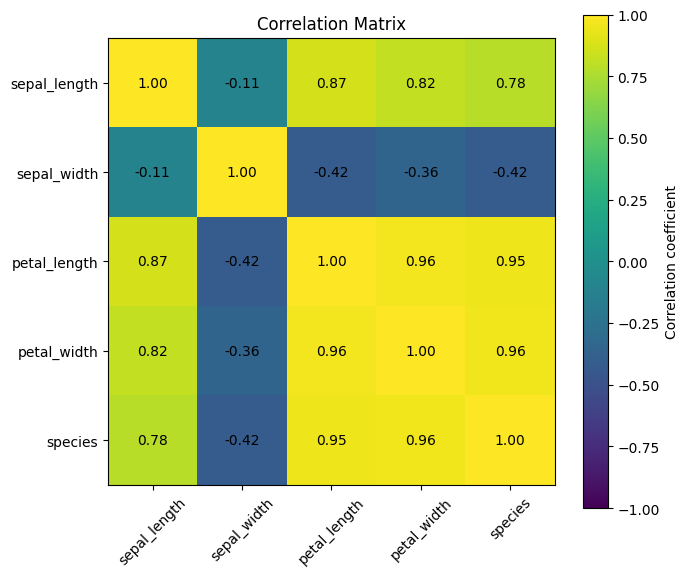

In [247]:

corr = iris.corr(numeric_only=True)

plt.figure(figsize=(7,6))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center",
                 va="center",
                 color="black")

cbar = plt.colorbar(im)
cbar.set_label("Correlation coefficient")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [248]:
#04-c Check the length of the x_train and x_test. If the numbers are 120 & 30, AWESOME!
#     You are good to continue!

In [249]:
print("len(x_train) =", len(x_train))
print("len(x_test)  =", len(x_test))

len(x_train) = 120
len(x_test)  = 30


In [250]:
if len(x_train) == 120 and len(x_test) == 30:
    print("AWESOME! ✅")
else:
    print("🤔")

AWESOME! ✅


In [251]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled.shape, x_test_scaled.shape)

(120, 4) (30, 4)


In [252]:
#05-a Convert y_train and y_test from categorical to one-hot encoded values, and call them
#     one_hot_train_labels, and one_hot_test_labels, respectively.

In [253]:
from tensorflow.keras.utils import to_categorical

one_hot_train_labels = to_categorical(y_train, num_classes=3)
one_hot_test_labels  = to_categorical(y_test,  num_classes=3)

print("one_hot_train_labels shape:", one_hot_train_labels.shape)
print("one_hot_test_labels shape :", one_hot_test_labels.shape)
print("Sample train labels:\n", one_hot_train_labels[:5])

one_hot_train_labels shape: (120, 3)
one_hot_test_labels shape : (30, 3)
Sample train labels:
 [[0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [254]:
#06-a Define a sequential model that contains 3 dense layers.
#     In the first and second layers, use 100 hidden units (neurons) and a 'relu' activation function.
#     For the last layer, we need to use 3 as the number of output,
#     and the reason is we have three classes (setosa -> 0, versicolor -> 1, virginica -> 2)
#     Also, please pick an appropriate loss function for the last layer.
#     (You may already have guessed what could be the best loss function when we have converted the categorical values to encoded values.)

In [255]:
import tensorflow as tf
import numpy as np
import random
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(123)
np.random.seed(123)
random.seed(123)

model = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(100, activation="relu"),
    layers.Dense(100, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 100)            │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,903 (42.59 KB)

 Trainable params: 10,903 (42.59 KB)

 Non-trainable params: 0 (0.00 B)

In [256]:
#06-b Now, compile your model using the 'rmsprop' optimizer, an appropriate loss function, and 'accuracy' for your metrics.

In [257]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [258]:
#07-a Train your model using epoch=20, batch=10.

In [259]:
history = model.fit(
    x_train_scaled,
    one_hot_train_labels,
    epochs=20,
    batch_size=10,
    validation_split=0.2,
    verbose=2
)

Epoch 1/20
10/10 - 1s - 104ms/step - accuracy: 0.7500 - loss: 0.7857 - val_accuracy: 0.7917 - val_loss: 0.6466
Epoch 2/20
10/10 - 0s - 13ms/step - accuracy: 0.7917 - loss: 0.5439 - val_accuracy: 0.7917 - val_loss: 0.5380
Epoch 3/20
10/10 - 0s - 11ms/step - accuracy: 0.8021 - loss: 0.4434 - val_accuracy: 0.8333 - val_loss: 0.4752
Epoch 4/20
10/10 - 0s - 12ms/step - accuracy: 0.8229 - loss: 0.3800 - val_accuracy: 0.8333 - val_loss: 0.4314
Epoch 5/20
10/10 - 0s - 11ms/step - accuracy: 0.8646 - loss: 0.3320 - val_accuracy: 0.8333 - val_loss: 0.3989
Epoch 6/20
10/10 - 0s - 11ms/step - accuracy: 0.8854 - loss: 0.2931 - val_accuracy: 0.8333 - val_loss: 0.3732
Epoch 7/20
10/10 - 0s - 11ms/step - accuracy: 0.9062 - loss: 0.2593 - val_accuracy: 0.8750 - val_loss: 0.3521
Epoch 8/20
10/10 - 0s - 11ms/step - accuracy: 0.9479 - loss: 0.2304 - val_accuracy: 0.8750 - val_loss: 0.3356
Epoch 9/20
10/10 - 0s - 11ms/step - accuracy: 0.9583 - loss: 0.2047 - val_accuracy: 0.8750 - val_loss: 0.3222
Epoch 10/

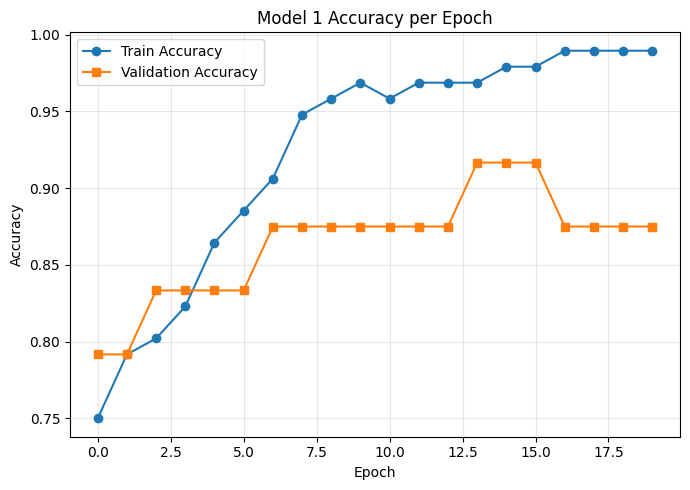

In [260]:
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="s", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 1 Accuracy per Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

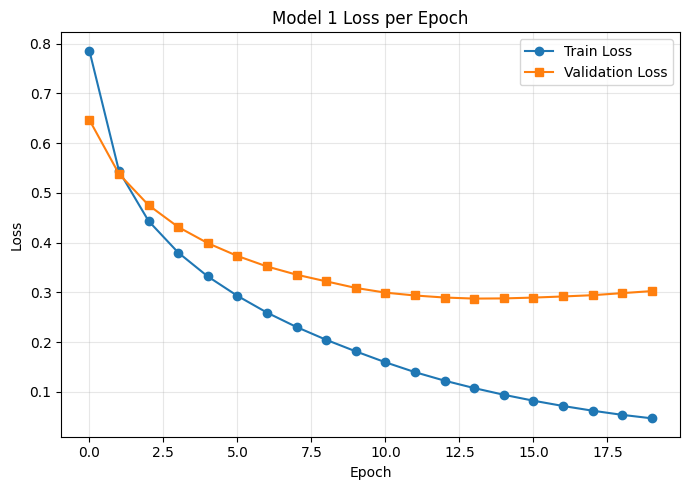

In [261]:
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 Loss per Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [262]:
#08-a Calculate the result, evaluating x_test and one_hot_test_label, and report on the accuracy of your model.

In [263]:
test_loss, test_acc = model.evaluate(x_test_scaled, one_hot_test_labels, verbose=0)
print("Test loss:", test_loss)
print(f"Test accuracy: {test_acc*100:.2f}%")

Test loss: 0.0909552350640297
Test accuracy: 96.67%


<Figure size 600x500 with 0 Axes>

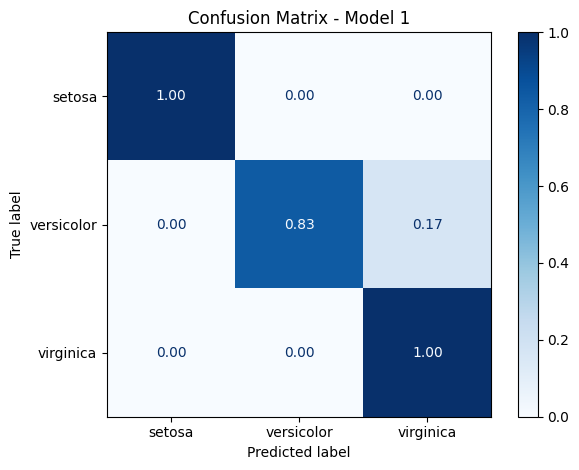


Classification Report - Model 1:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.83      0.91         6
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



In [264]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


y_pred1 = np.argmax(model.predict(x_test_scaled, verbose=0), axis=1)
cm1_norm = confusion_matrix(y_test, y_pred1, normalize="true")

plt.figure(figsize=(6,5))
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm1_norm,
    display_labels=["setosa", "versicolor", "virginica"]
)

disp1.plot(cmap="Blues", values_format=".2f")
plt.title("Confusion Matrix - Model 1")
plt.grid(False)
plt.tight_layout()
plt.show()

print("\nClassification Report - Model 1:\n")
print(classification_report(
    y_test,
    y_pred1,
    target_names=["setosa", "versicolor", "virginica"],
    zero_division=0
))

In [265]:
#09-a Now, we repeat all we have done in #06-a with the following parameters:
#     In the first and second hidden layers, use 10 hidden units (neurons) and a 'relu' activation function.
#     For the output layer, we need to use 3.

In [266]:
tf.random.set_seed(123)
np.random.seed(123)
random.seed(123)

model2 = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(10, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model2.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [267]:
#09-b Use the same settings as for #06-b (compile using the same optimizer, loss function) and output the accuracy

In [268]:
model2.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [269]:
#09-c Please fit your model using epoch=4, batch=10.

In [270]:
history2 = model2.fit(
    x_train_scaled,
    one_hot_train_labels,
    epochs=4,
    batch_size=10,
    validation_split=0.2,
    verbose=2
)

Epoch 1/4
10/10 - 1s - 122ms/step - accuracy: 0.3333 - loss: 1.1353 - val_accuracy: 0.3750 - val_loss: 1.1036
Epoch 2/4
10/10 - 0s - 12ms/step - accuracy: 0.3333 - loss: 1.0782 - val_accuracy: 0.3750 - val_loss: 1.0640
Epoch 3/4
10/10 - 0s - 10ms/step - accuracy: 0.4062 - loss: 1.0363 - val_accuracy: 0.4167 - val_loss: 1.0302
Epoch 4/4
10/10 - 0s - 10ms/step - accuracy: 0.5833 - loss: 0.9967 - val_accuracy: 0.5000 - val_loss: 0.9988


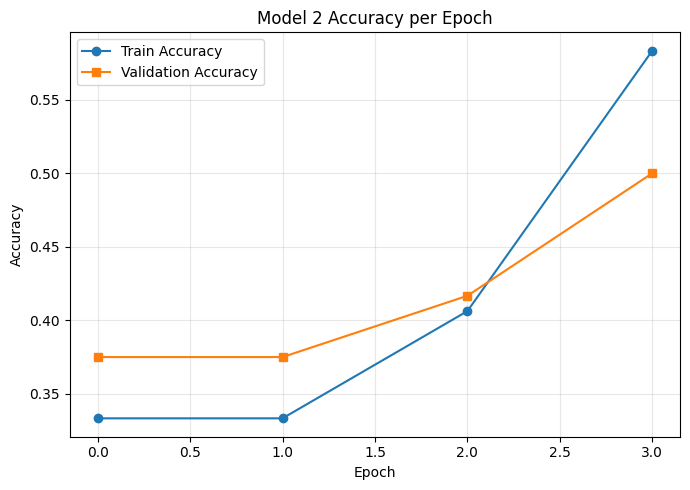

In [271]:
plt.figure(figsize=(7,5))

plt.plot(history2.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history2.history["val_accuracy"], marker="s", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 Accuracy per Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

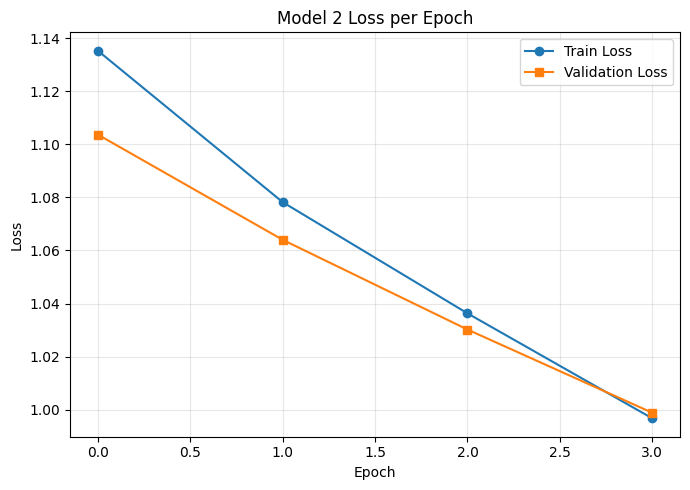

In [272]:
plt.figure(figsize=(7,5))

plt.plot(history2.history["loss"], marker="o", label="Train Loss")
plt.plot(history2.history["val_loss"], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Loss per Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [273]:
#09-d Calculate the result, evaluating x_test and one_hot_test_label, and report on the accuracy of your model.

In [274]:
test_loss2, test_acc2 = model2.evaluate(x_test_scaled, one_hot_test_labels, verbose=0)
print("Model2 Test loss:", test_loss2)
print(f"Model2 Test accuracy: {test_acc2*100:.2f}%")

Model2 Test loss: 0.9454715251922607
Model2 Test accuracy: 60.00%


<Figure size 600x500 with 0 Axes>

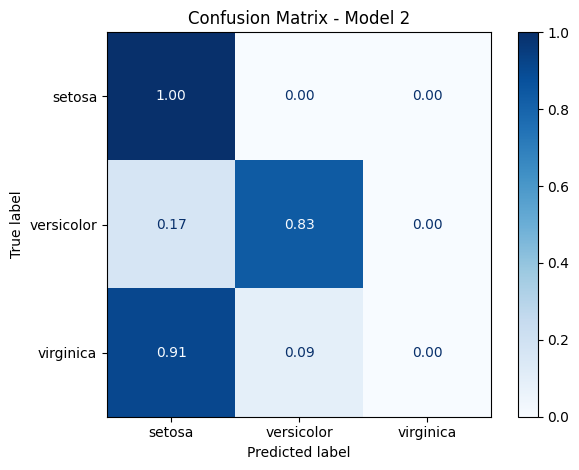


Classification Report - Model 2:

              precision    recall  f1-score   support

      setosa       0.54      1.00      0.70        13
  versicolor       0.83      0.83      0.83         6
   virginica       0.00      0.00      0.00        11

    accuracy                           0.60        30
   macro avg       0.46      0.61      0.51        30
weighted avg       0.40      0.60      0.47        30



In [275]:
y_pred2 = np.argmax(model2.predict(x_test_scaled, verbose=0), axis=1)
cm2_norm = confusion_matrix(y_test, y_pred2, normalize="true")

plt.figure(figsize=(6,5))
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2_norm,
    display_labels=["setosa", "versicolor", "virginica"]
)

disp2.plot(cmap="Blues", values_format=".2f")
plt.title("Confusion Matrix - Model 2")
plt.grid(False)
plt.tight_layout()
plt.show()

print("\nClassification Report - Model 2:\n")
print(classification_report(
    y_test,
    y_pred2,
    target_names=["setosa", "versicolor", "virginica"],
    zero_division=0
))

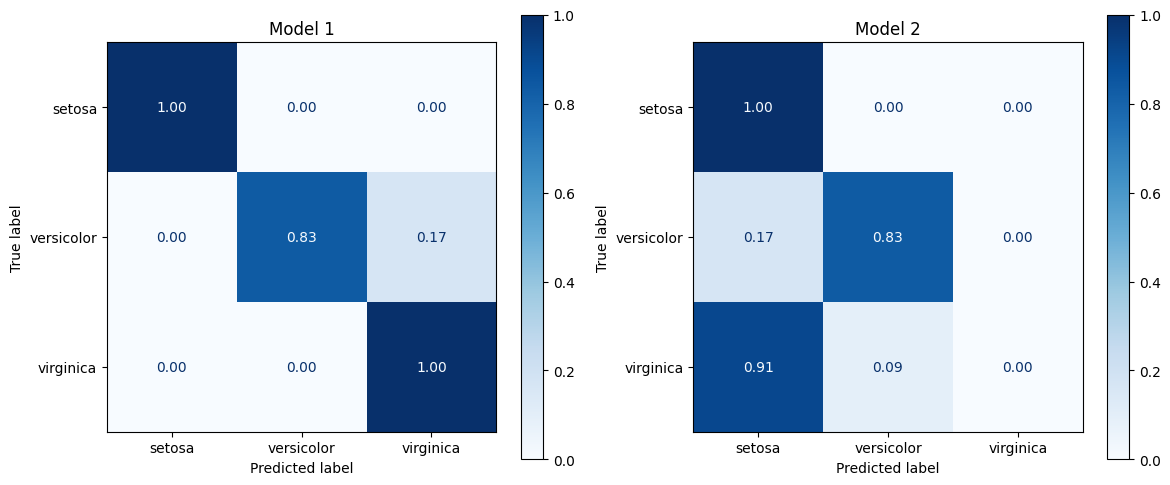

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

disp1.plot(ax=axes[0], cmap="Blues", values_format=".2f")
axes[0].set_title("Model 1")

disp2.plot(ax=axes[1], cmap="Blues", values_format=".2f")
axes[1].set_title("Model 2")

plt.tight_layout()
plt.show()

In [277]:
#10-a In your video submission, explain each line of your code, and the arguments you've used
# Ensure to answer the following questions at a minimum:
# 10-a-i) How the number of layers or hidden units could impact the accuracy of our model.
# 10-a-ii) Do we always suffer from overfitting?
# 10-a-iii) How can we detect overfitting?
# 10-a-iv) How can we reduce overfitting?

# 10 – Discussion

---

## 🔹 10-a-i) How do layers and hidden units affect accuracy?

Increasing the number of layers or neurons increases the **model’s capacity**.  
This allows the network to learn more complex patterns and may improve accuracy on harder problems.

However, for small datasets like Iris:

- Too many layers/neurons → risk of **overfitting**
- Too few layers/neurons → **underfitting**
- A balanced architecture usually performs best

---

## 🔹 10-a-ii) Do we always suffer from overfitting?

No.

Overfitting occurs when the model is too complex for the dataset or trained for too many epochs.  
In simpler models or with limited training time, we often observe **underfitting instead**.

---

## 🔹 10-a-iii) How can we detect overfitting?

We detect overfitting by comparing **training vs validation performance**:

- Training accuracy keeps increasing  
- Validation accuracy stops improving or decreases  
- Training loss decreases while validation loss increases  

This divergence indicates overfitting.

---

## 🔹 10-a-iv) How can we reduce overfitting?

We can reduce overfitting by:

- Using fewer layers or neurons  
- Reducing the number of epochs or applying **EarlyStopping**  
- Adding regularization (Dropout, L2)  
- Increasing the dataset size  

---

Model performance strongly depends on architecture and training parameters.  
Finding the right balance between capacity and generalization is key.

In [278]:
#10-b
# Use different settings than the ones we chose in #09
# Change each of the following once:
#   i)   optimizer
#   ii)  number of layers
#   iii) hidden units
#   iv)  number of epochs
#   v)   batch_size
# Change one parameter at a time, and rerun the cell(s), then explain the output

In [279]:
def build_and_run(optimizer="rmsprop", hidden_units=10, extra_layer=False, epochs=4, batch_size=10):
    tf.random.set_seed(123)
    np.random.seed(123)
    random.seed(123)

    layers_list = [keras.Input(shape=(4,)),
                   layers.Dense(hidden_units, activation="relu"),
                   layers.Dense(hidden_units, activation="relu")]
    if extra_layer:
        layers_list.append(layers.Dense(hidden_units, activation="relu"))
    layers_list.append(layers.Dense(3, activation="softmax"))

    m = keras.Sequential(layers_list)
    m.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

    m.fit(x_train_scaled, one_hot_train_labels, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)
    loss, acc = m.evaluate(x_test_scaled, one_hot_test_labels, verbose=0)

    print(f"optimizer={optimizer}, units={hidden_units}, extra_layer={extra_layer}, epochs={epochs}, batch={batch_size} -> acc={acc*100:.2f}%")

In [280]:
#   i)   optimizer
build_and_run(optimizer="adam")

optimizer=adam, units=10, extra_layer=False, epochs=4, batch=10 -> acc=53.33%


In [281]:
#   ii)  number of layers
build_and_run(extra_layer=True)

optimizer=rmsprop, units=10, extra_layer=True, epochs=4, batch=10 -> acc=76.67%


In [282]:
#   iii) hidden units
build_and_run(hidden_units=50)

optimizer=rmsprop, units=50, extra_layer=False, epochs=4, batch=10 -> acc=93.33%


In [283]:
#   iv)  number of epochs
build_and_run(epochs=20)

optimizer=rmsprop, units=10, extra_layer=False, epochs=20, batch=10 -> acc=96.67%


In [284]:
#   v)   batch_size
build_and_run(batch_size=5)

optimizer=rmsprop, units=10, extra_layer=False, epochs=4, batch=5 -> acc=73.33%


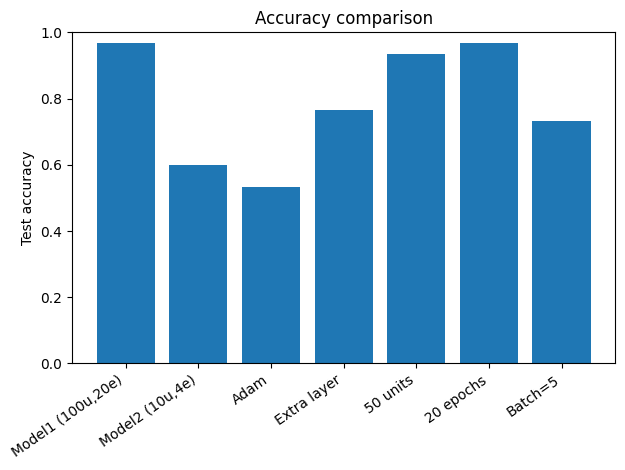

In [285]:
labels = [
    "Model1 (100u,20e)",
    "Model2 (10u,4e)",
    "Adam",
    "Extra layer",
    "50 units",
    "20 epochs",
    "Batch=5",
]

acc = [
    test_acc,
    test_acc2,
    0.5333,
    0.7667,
    0.9333,
    0.9667,
    0.7333,
]

plt.figure()
plt.bar(labels, acc)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Test accuracy")
plt.title("Accuracy comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---
# Deliverables:
1. Submit the current ipynb file on D2L
2. Please record and upload to YouTube 3-6 minute recorded video clip (aim for 5 minutes) describing the answers to the questions above, espcially #10.

Notes:
- In your submission, YOU MUST SUBMIT A LINK TO YOUR YOUTUBE VIDEO as a TEXT SUBMISSION SECTION on your D2L submission.
- Omitting this D2L comment will result in a 0% for your total mark.